# Bibliotecas

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
cd /content/drive/MyDrive/ciencia_de_datos/modulo4/proyecto_tumores/

/content/drive/MyDrive/ciencia_de_datos/modulo4/proyecto_tumores


In [2]:
import pandas as pd
from datetime import datetime, date, timedelta, time
import plotly.express as px
import matplotlib.pyplot as plt
import pandas_datareader as pdr
import numpy as np
import seaborn as sns
import glob
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, GlobalAveragePooling2D
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
from keras.models import Sequential
from tensorflow.keras import layers, Model, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV2

import gc
from tensorflow.keras import backend as K

# Split de rutas train / val

In [ ]:
df = pd.read_csv('datos.csv', sep=',')

In [ ]:
diags = ['no_tumor','glioma','meningioma','pituitary']

In [ ]:
for n, diag in enumerate(diags):
    df[diag] = df[diag].map({1:n, 0:0})
df['enfermo'] = df[['glioma','meningioma','pituitary']].max(axis=1).map(dict(enumerate(diags)))
df.drop(columns=diags, inplace=True)
df

,imagen,enfermo
0,./tumores-cerebrales-mri-dataset/glioma/G_1.jpg,glioma
1,./tumores-cerebrales-mri-dataset/glioma/G_10.jpg,glioma
2,./tumores-cerebrales-mri-dataset/glioma/G_100.jpg,glioma
3,./tumores-cerebrales-mri-dataset/glioma/G_100_...,glioma
4,./tumores-cerebrales-mri-dataset/glioma/G_100_...,glioma
...,...,...
43995,./tumores-cerebrales-mri-dataset/pituitary/ima...,pituitary
43996,./tumores-cerebrales-mri-dataset/pituitary/ima...,pituitary
43997,./tumores-cerebrales-mri-dataset/pituitary/ima...,pituitary
43998,./tumores-cerebrales-mri-dataset/pituitary/ima...,pituitary


In [ ]:
df.enfermo.value_counts()

,count
enfermo,
glioma,11000
meningioma,11000
no_tumor,11000
pituitary,11000


In [ ]:
rutas_train, rutas_test = train_test_split(df, test_size=0.25, shuffle=True)
rutas_test, rutas_val = train_test_split(rutas_test, test_size=0.2, shuffle=True)
rutas_train.shape, rutas_test.shape, rutas_val.shape

((33000, 2), (8800, 2), (2200, 2))

In [17]:
rutas_train.shape[0]/44000, rutas_test.shape[0]/44000, rutas_val.shape[0]/44000, 0.95*0.2, 6600+1760

(0.75, 0.2, 0.05, 0.19, 8360)

In [ ]:
rutas_train.to_csv('rutas_train.csv', sep='|', index=False)
rutas_test.to_csv('rutas_test.csv', sep='|', index=False)
rutas_val.to_csv('rutas_val.csv', sep='|', index=False)

# Generadores

In [6]:
rutas_train = pd.read_csv('rutas_train.csv', sep='|')
rutas_test = pd.read_csv('rutas_test.csv', sep='|')
rutas_val = pd.read_csv('rutas_val.csv', sep='|')

rutas_train.shape, rutas_test.shape, rutas_val.shape

FileNotFoundError: [Errno 2] No such file or directory: 'rutas_train.csv'

In [ ]:
tgt_size = (224, 224)
batch = 64
CLASS_MODE = 'categorical'

In [ ]:
gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)
gen_test = ImageDataGenerator(rescale=1./255)
gen_val = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = gen_train.flow_from_dataframe(dataframe=rutas_train_s,
                                                x_col='imagen',
                                                y_col='enfermo',
                                                class_mode=CLASS_MODE,
                                                subset="training",
                                                batch_size= batch,
                                                target_size=tgt_size,
                                                shuffle=True
                                                )

test_generator = gen_train.flow_from_dataframe(dataframe=rutas_train_s,
                                                x_col='imagen',
                                                y_col='enfermo',
                                                class_mode=CLASS_MODE,
                                                subset="validation",
                                                batch_size= batch,
                                                target_size=tgt_size,
                                                shuffle=False
                                                )

val_generator = gen_val.flow_from_dataframe(dataframe=rutas_val,
                                                x_col='imagen',
                                                y_col='enfermo',
                                                class_mode=CLASS_MODE,
                                                batch_size= batch,
                                                target_size=tgt_size,
                                                )

Found 5280 validated image filenames belonging to 4 classes.
Found 1320 validated image filenames belonging to 4 classes.
Found 2200 validated image filenames belonging to 4 classes.


# Modelado

## Modelo sencillo CONV

In [ ]:
model = Sequential()

# parte convolucional
model.add(Conv2D(64, 3, padding = 'same', activation = 'relu', input_shape=(*tgt_size, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(32, 3, padding = 'same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

# Flattenging + Capas densas
model.add(GlobalAveragePooling2D())

model.add(Dense(32, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation = 'relu'))
model.add(Dense(4, activation="softmax"))

model.summary()

c:\Users\Mateo Márquez\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,292 (87.08 KB)

 Trainable params: 22,100 (86.33 KB)

 Non-trainable params: 192 (768.00 B)

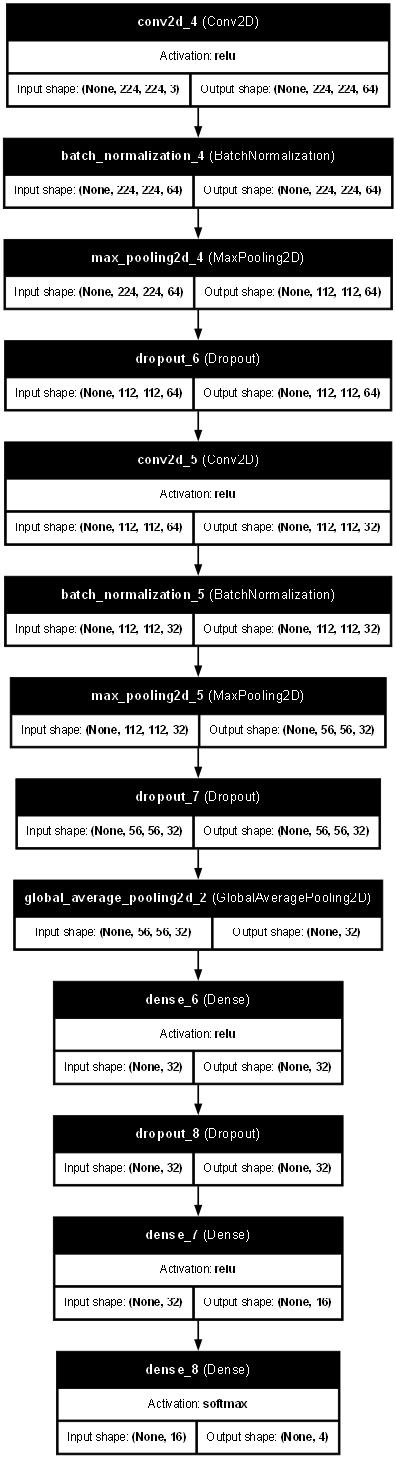

In [ ]:
plot_model(model, "model0.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, dpi=60)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True, verbose=1
)

In [ ]:
history = model.fit(train_generator,
                    epochs=10,
                    #batch_size=batch,
                    validation_data=test_generator,
                    callbacks=[early_stop]
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 77s 11s/step - accuracy: 0.2695 - loss: 1.4316 - val_accuracy: 0.2286 - val_loss: 1.3853
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 11s/step - accuracy: 0.3582 - loss: 1.3375 - val_accuracy: 0.2286 - val_loss: 1.3874
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 62s 12s/step - accuracy: 0.3794 - loss: 1.3082 - val_accuracy: 0.2571 - val_loss: 1.3898
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 62s 12s/step - accuracy: 0.3865 - loss: 1.2924 - val_accuracy: 0.2857 - val_loss: 1.3921
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 104s 25s/step - accuracy: 0.4184 - loss: 1.2785 - val_accuracy: 0.2143 - val_loss: 1.3940
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 10s/step - accuracy: 0.4504 - loss: 1.2441 - val_accuracy: 0.2143 - val_loss: 1.3984
Epoch 7/10
2/5 ━━━━━━━━━━━━━━━━━━━━ 1:01 20s/step - accuracy: 0.4609 - loss: 1.2480

KeyboardInterrupt: 

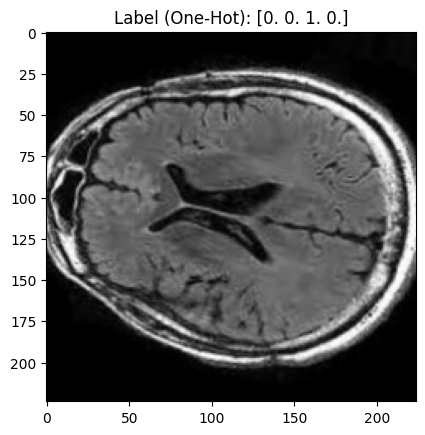

Forma del batch de imágenes: (64, 224, 224, 3)
Forma del batch de etiquetas: (64, 4)
Valores de píxeles: min=0.0, max=1.0


In [ ]:
import matplotlib.pyplot as plt

# Extraer un batch
images, labels = next(iter(train_generator))

# Ver una imagen
plt.imshow(images[0])
plt.title(f"Label (One-Hot): {labels[0]}")
plt.show()

# Ver las dimensiones
print(f"Forma del batch de imágenes: {images.shape}")
print(f"Forma del batch de etiquetas: {labels.shape}")
print(f"Valores de píxeles: min={images.min()}, max={images.max()}")

In [ ]:
K.clear_session()
gc.collect()

2889

In [ ]:
model = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Bloque 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Bloque 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(4, activation='softmax')
])

## Modelo Tranfer Learning: MobileNetV2 + Fine Tuning

In [3]:
def reporting_val(model, val_ds):
    print("Generando predicciones")
    y_true = []
    for images, labels in val_ds:
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_pred_probs = model.predict(val_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    fig = px.imshow(
        cm,
        labels=dict(x="Predicción del Modelo", y="Etiqueta Real", color="Frecuencia"),
        x=class_names,
        y=class_names,
        text_auto='.1%', # Formato de los números (puedes usar '.0f' si prefieres enteros)
        color_continuous_scale='Blues',
        title="Matriz de Confusión"
    )

    fig.update_layout(
        xaxis_title="Predicción del Modelo",
        yaxis_title="Etiqueta Real"
    )

    fig.show()

In [4]:
def reporting_val_professional(model, val_ds, titulo='Matriz de Confusión Normalizada', class_names=['glioma', 'meningioma', 'no_tumor', 'pituitary']):
    """
    Genera predicciones, imprime el reporte de clasificación y visualiza una matriz
    de confusión normalizada con una estética sobria y profesional compatible con
    informes científicos.
    """
    print("Generando predicciones sobre el conjunto de validación...")

    # 1. Extraer y_true y calcular y_pred
    y_true = []
    for _, labels in tqdm(val_ds):
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_pred_probs = model.predict(val_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 2. Imprimir el Classification Report (Métricas de Ingeniería)
    print("\n" + "="*40)
    print("       REPORTE DE CLASIFICACIÓN (Métricas Técnica)")
    print("="*40)
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("="*40)

    # 3. Calcular la Matriz de Confusión Normalizada
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # 4. Crear el Heatmap con go.Heatmap (Estilo Sobrio)
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=class_names,
        y=class_names,
        colorscale='Greens',
        reversescale=False,
        showscale=True,
        colorbar=dict(
            title="Frecuencia",
            titleside="top",
            tickformat=".1%", # Muestra porcentajes en la barra lateral
            thickness=15,
            len=0.7
        ),
        hoverongaps=False,
        # Herramienta para asegurar que el texto sea visible (color blanco sobre fondo oscuro)
        text=np.vectorize(lambda x: f'<b>{x:.1%}</b>')(cm), # Texto con negrita y formato
        texttemplate="%{text}",
        textfont={"size": 13, "family": "Arial"} # Fuente por defecto
    ))

    # 5. Estilización para coherencia con el gráfico de historial
    fig.update_layout(
        title_text=f"<b>{titulo}</b>",
        template="plotly_white",
        xaxis=dict(
            title="Predicción del Modelo",
            side="bottom",
            tickangle=0,
            showgrid=False,
            # Asegura que las etiquetas no se corten
            automargin=True
        ),
        yaxis=dict(
            title="Etiqueta Real",
            autorange="reversed", # Invierte para que el origen esté arriba a la izquierda
            showgrid=False,
            automargin=True
        ),
        font=dict(family="Arial", size=12),
        width=600,  # Un tamaño cuadrado para mejor visualización
        height=600,
        margin=dict(l=80, r=30, t=100, b=80),
        # Truco para que el texto cambie de color según el fondo
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    # 6. Mostrar el gráfico
    fig.show()

In [5]:
def load_and_preprocess(path, label, tgt_size, num_classes):
    # Cargar imagen
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, tgt_size)
    image = image / 255.0  # Normalización

    # One-hot encoding de la etiqueta
    label = tf.one_hot(label, num_classes)

    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

def build_dataset(paths, labels, tgt_size, num_classes, is_training=True, batch_size=32):
    # Crear dataset desde listas (paths son strings, labels son int)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Usamos una lambda para pasar los argumentos extra (tgt_size, num_classes)
    # que la función de map no conoce nativamente
    dataset = dataset.map(
        lambda x, y: load_and_preprocess(x, y, tgt_size, num_classes),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch y rendimiento
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

### Construcción de rutas train, test y val

In [5]:
frac_train = 0.2

In [6]:
rutas_train_s = rutas_train.sample(frac=frac_train, random_state=1984)
rutas_test_s = rutas_test.sample(frac=frac_train, random_state=1984)
#rutas_val_s = rutas_val.sample(frac=0.2, random_state=1984)
rutas_train_s.shape, rutas_test_s.shape

NameError: name 'rutas_train' is not defined

In [3]:
classes = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
num_classes = len(classes)
class_map = {name: i for i, name in enumerate(classes)}

In [15]:
class_weights = {
    0: 2.0, # glioma
    1: 1.5, # meningioma
    2: 0.7, # no_tumor
    3: 1.5  # pituitary
}

In [4]:
# Construir los datasets muestra
y_train_indices = [class_map[x] for x in rutas_train_s['enfermo']]
y_test_indices = [class_map[x] for x in rutas_test_s['enfermo']]
y_val_indices = [class_map[x] for x in rutas_val['enfermo']]

train_ds = build_dataset(paths=rutas_train_s['imagen'], labels=y_train_indices, is_training=True, batch_size=batch, tgt_size=tgt_size, num_classes=4)

test_ds = build_dataset(rutas_test_s['imagen'], y_test_indices, is_training=False, batch_size=batch, tgt_size=tgt_size, num_classes=4)

val_ds = build_dataset(rutas_val['imagen'], y_val_indices, is_training=False, batch_size=batch, tgt_size=tgt_size, num_classes=4) # con este voy a validar

NameError: name 'rutas_train_s' is not defined

In [17]:
# Construir los datasets completos
y_train_indices_f = [class_map[x] for x in rutas_train['enfermo']]
y_test_indices_f = [class_map[x] for x in rutas_test['enfermo']]

train_ds_f = build_dataset(paths=rutas_train['imagen'], labels=y_train_indices_f, is_training=True, batch_size=batch, tgt_size=tgt_size, num_classes=4)

test_ds_f = build_dataset(paths=rutas_test['imagen'], labels=y_test_indices_f, is_training=True, batch_size=batch, tgt_size=tgt_size, num_classes=4)

### Arquitectura

In [20]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*tgt_size, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(4, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


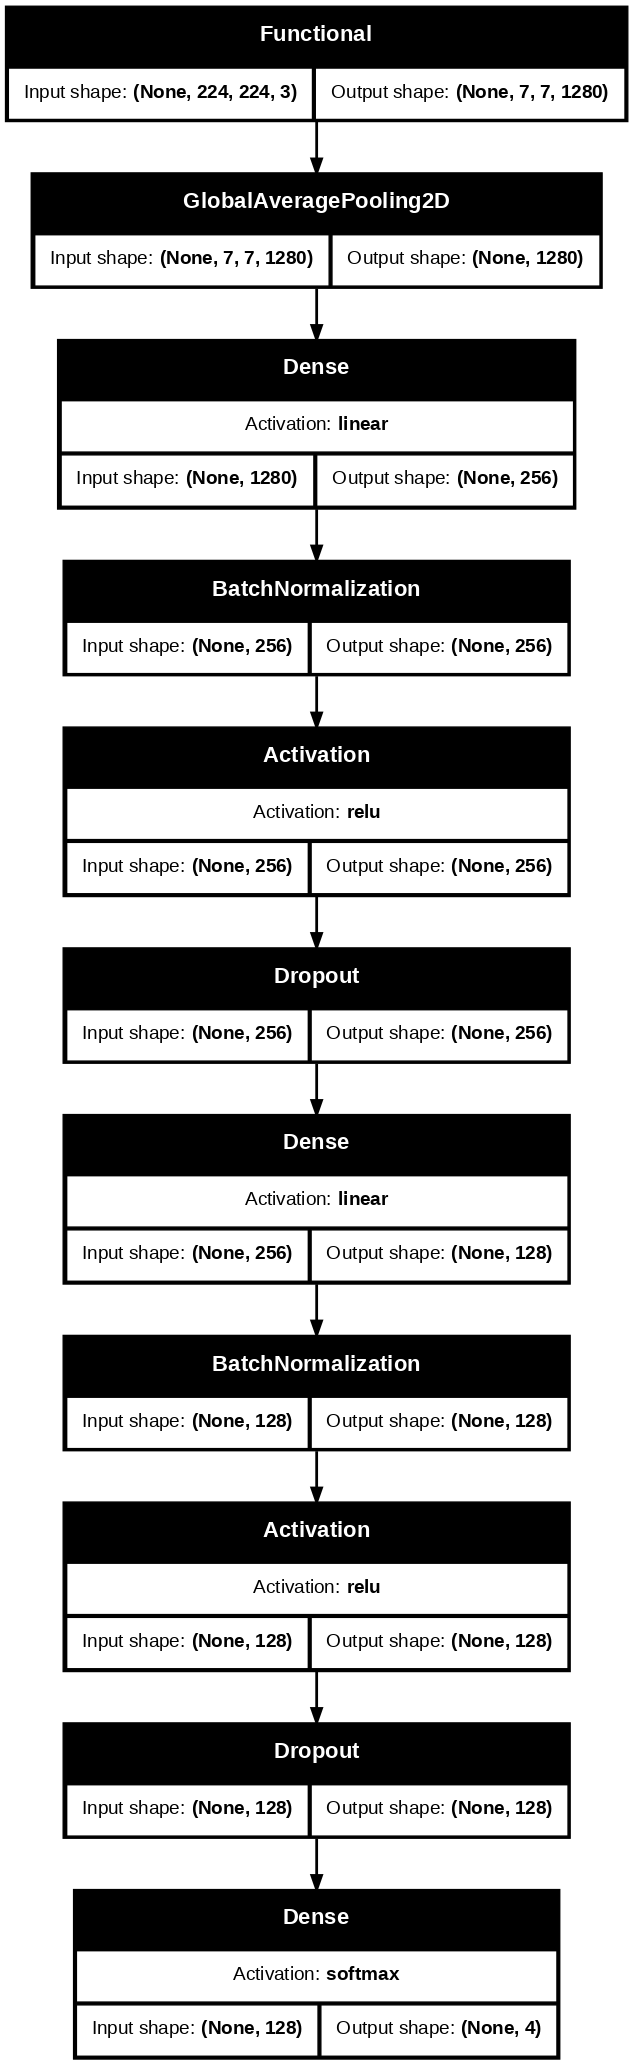

In [32]:
tf.keras.utils.plot_model(model, 'modelo_arquitectura.png', show_shapes=True, show_layer_names=False, dpi=100, rankdir='TB', show_layer_activations=True)

### Fit() #1 - 20% de imagenes

#### Entrenamiento

In [ ]:

model.compile(optimizer=Adam(learning_rate=5e-4), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
checkpoint = ModelCheckpoint('./models/TL_base/model_frac_0.2_{val_accuracy:.3f}.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
# Entrenar
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6034 - loss: 1.4149
Epoch 1: val_accuracy improved from None to 0.82216, saving model to ./models/TL_base/model_frac_0.2_0.822.keras

Epoch 1: finished saving model to ./models/TL_base/model_frac_0.2_0.822.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 64s 448ms/step - accuracy: 0.7027 - loss: 1.0696 - val_accuracy: 0.8222 - val_loss: 0.4934 - learning_rate: 5.0000e-04
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8087 - loss: 0.7041
Epoch 2: val_accuracy improved from 0.82216 to 0.86193, saving model to ./models/TL_base/model_frac_0.2_0.862.keras

Epoch 2: finished saving model to ./models/TL_base/model_frac_0.2_0.862.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 42s 356ms/step - accuracy: 0.8241 - loss: 0.6582 - val_accuracy: 0.8619 - val_loss: 0.3905 - learning_rate: 5.0000e-04
Epoch 3/20
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8606 - loss: 0.5550
Epoch 3: val_accuracy improved from 0.86193 to 0.8750

In [ ]:
px.line(history.history, y=['loss', 'val_loss', 'accuracy', 'val_accuracy'], title='Desempeño - Fit #1')

#### Reporting

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

In [18]:
model = tf.keras.models.load_model('./models/TL_base/model_frac_0.2_0.911.keras')

In [ ]:
print("Dispositivos disponibles:", tf.config.list_physical_devices('GPU'))

In [21]:
# Aplica esto a tu conjunto de validación antes de pasarlo a la función
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [34]:
reporting_val_professional(model, val_ds, 'Matriz de Confusión: Foreman974-20 - Estabilización')

Generando predicciones sobre el conjunto de validación...


100%|██████████| 35/35 [00:00<00:00, 1817.22it/s]

 2/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step

       REPORTE DE CLASIFICACIÓN (Métricas Técnica)
              precision    recall  f1-score   support

      glioma       0.94      0.86      0.90       579
  meningioma       0.83      0.86      0.84       531
    no_tumor       0.95      0.97      0.96       535
   pituitary       0.93      0.96      0.94       555

    accuracy                           0.91      2200
   macro avg       0.91      0.91      0.91      2200
weighted avg       0.91      0.91      0.91      2200



In [35]:
reporting_val(model, val_ds)

Generando predicciones
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.94      0.86      0.90       579
  meningioma       0.83      0.86      0.84       531
    no_tumor       0.95      0.97      0.96       535
   pituitary       0.93      0.96      0.94       555

    accuracy                           0.91      2200
   macro avg       0.91      0.91      0.91      2200
weighted avg       0.91      0.91      0.91      2200



### Fine Tuning - 100% de imagenes

#### Entrenamiento

In [ ]:
base_model = model.layers[0]
base_model.trainable = True
fine_tune_at = -20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
checkpoint_ft = ModelCheckpoint('./models/TL_fine_tune/model_frac_1.0_layers_20_{val_accuracy:.3f}.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

history_fine = model.fit(
    train_ds_f,
    epochs=15,
    validation_data=test_ds_f,
    callbacks=[reduce_lr, checkpoint_ft],
    class_weight=class_weights
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7977 - loss: 0.8293
Epoch 1: val_accuracy improved from None to 0.88818, saving model to ./models/TL_fine_tune/model_frac_1.0_layers_20_0.888.keras

Epoch 1: finished saving model to ./models/TL_fine_tune/model_frac_1.0_layers_20_0.888.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 188s 322ms/step - accuracy: 0.8354 - loss: 0.6647 - val_accuracy: 0.8882 - val_loss: 0.3323 - learning_rate: 1.0000e-05
Epoch 2/15
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8796 - loss: 0.4809
Epoch 2: val_accuracy improved from 0.88818 to 0.91591, saving model to ./models/TL_fine_tune/model_frac_1.0_layers_20_0.916.keras

Epoch 2: finished saving model to ./models/TL_fine_tune/model_frac_1.0_layers_20_0.916.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 159s 301ms/step - accuracy: 0.8902 - loss: 0.4361 - val_accuracy: 0.9159 - val_loss: 0.2296 - learning_rate: 1.0000e-05
Epoch 3/15
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9094 - loss

In [ ]:
px.line(history_fine.history, y=['loss', 'val_loss', 'accuracy', 'val_accuracy'], title='Desempeño - Fine Tuning')

### Reporting

In [30]:
model_ft_10lys = tf.keras.models.load_model('./models/TL_fine_tune/model_frac_1.0_0.965.keras')

In [37]:
model_ft_20lys = tf.keras.models.load_model('./models/TL_fine_tune/model_frac_1.0_layers_20_0.974.keras')

In [1]:
%%time
reporting_val_professional(model_ft_10lys, val_ds, 'Matriz de Confusión: Foreman974-10 - Generalización')

CPU times: total: 0 ns
Wall time: 997 μs


NameError: name 'reporting_val_professional' is not defined

In [40]:
reporting_val_professional(model_ft_20lys, val_ds, 'Matriz de Confusión: Foreman974-20 - Generalización')

Generando predicciones sobre el conjunto de validación...


100%|██████████| 35/35 [00:00<00:00, 2531.92it/s]

 3/35 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step

       REPORTE DE CLASIFICACIÓN (Métricas Técnica)
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       579
  meningioma       0.94      0.98      0.96       531
    no_tumor       0.99      0.99      0.99       535
   pituitary       0.99      0.98      0.98       555

    accuracy                           0.98      2200
   macro avg       0.98      0.98      0.98      2200
weighted avg       0.98      0.98      0.98      2200



In [ ]:
reporting_val(model_ft_10lys, val_ds)
reporting_val(model_ft_20lys, val_ds)

Generando predicciones
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.98      0.94      0.96       579
  meningioma       0.91      0.95      0.93       531
    no_tumor       0.99      0.97      0.98       535
   pituitary       0.97      0.98      0.97       555

    accuracy                           0.96      2200
   macro avg       0.96      0.96      0.96      2200
weighted avg       0.96      0.96      0.96      2200



Generando predicciones
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 337ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       579
  meningioma       0.94      0.98      0.96       531
    no_tumor       0.99      0.99      0.99       535
   pituitary       0.99      0.98      0.98       555

    accuracy                           0.98      2200
   macro avg       0.98      0.98      0.98      2200
weighted avg       0.98      0.98      0.98      2200



In [61]:
history1 = pd.read_csv('history_fit1.csv')
# 1. Configuración de la figura con eje secundario (Dual Axis)
fig = make_subplots(specs=[[{"secondary_y": True}]])

best_epoch = 7
best_val_loss = history1.loc[best_epoch, 'val_loss']

# 2. Agregar trazas de Accuracy (Eje izquierdo)
fig.add_trace(
    go.Scatter(x=history1.index, y=history1['acc'], name="Accuracy (Train)",
               line=dict(color='#2E86C1', width=2)),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=history1.index, y=history1['val_acc'], name="Accuracy (Val)",
               line=dict(color='#2E86C1', width=2, dash='dash')),
    secondary_y=False,
)

# 3. Agregar trazas de Loss (Eje derecho)
fig.add_trace(
    go.Scatter(x=history1.index, y=history1['loss'], name="Loss (Train)",
               line=dict(color='#C0392B', width=2)),
    secondary_y=True,
)
fig.add_trace(
    go.Scatter(x=history1.index, y=history1['val_loss'], name="Loss (Val)",
               line=dict(color='#C0392B', width=2, dash='dash')),
    secondary_y=True,
)

# 5. NUEVO: Agregar el círculo distintivo sobre el punto elegido
fig.add_trace(
    go.Scatter(
        x=[best_epoch],
        y=[best_val_loss],
        mode='markers',
        marker=dict(color='#C0392B', size=18, symbol='circle-open', line=dict(width=3)),
        name="Modelo Elegido",
        showlegend=False # No lo agregamos a la leyenda principal para no saturar
    ),
    secondary_y=True
)

# 6. NUEVO: Agregar la anotación profesional
fig.add_annotation(
    x=best_epoch,
    y=best_val_loss,
    xref="x",
    yref="y2", # Importante: referenciar al eje derecho (Loss)
    text=f"<b>Punto Óptimo: Época {best_epoch}</b><br>val_loss: {best_val_loss:.4f}<br>Modelo seleccionado<br>para Fine Tuning",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#C0392B",
    ax=70, # Ajuste horizontal de la caja de texto
    ay=-70, # Ajuste vertical de la caja de texto
    bordercolor="#C0392B",
    borderwidth=1,
    borderpad=6,
    bgcolor="#FFFFFF",
    opacity=0.9,
    font=dict(color="#C0392B", size=11)
)

# 4. Estilización para un look sobrio y profesional
fig.update_layout(
    title_text="<b>Evolución del entrenamiento: Foreman974-20 - Estabilización</b>",
    template="plotly_white",
    xaxis=dict(title="Época", showgrid=True, gridcolor='#F0F0F0'),
    yaxis=dict(title="Accuracy", range=[0.7, 1.0], showgrid=True, gridcolor='#F0F0F0'),
    yaxis2=dict(title="Loss", range=[0, 0.7], showgrid=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    font=dict(family="Arial", size=16),
    margin=dict(l=50, r=50, t=80, b=50)
)
fig.show()

In [59]:
history2 = pd.read_csv('history_fit2.csv')
# 1. Configuración de la figura con eje secundario (Dual Axis)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 2. Agregar trazas de Accuracy (Eje izquierdo)
fig.add_trace(
    go.Scatter(x=history2.index, y=history2['acc'], name="Accuracy (Train)",
               line=dict(color='#2E86C1', width=2), mode='lines'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=history2.index, y=history2['val_acc'], name="Accuracy (Val)",
               line=dict(color='#2E86C1', width=2, dash='dash'), mode='lines'),
    secondary_y=False,
)

# 3. Agregar trazas de Loss (Eje derecho)
fig.add_trace(
    go.Scatter(x=history2.index, y=history2['loss'], name="Loss (Train)",
               line=dict(color='#C0392B', width=2), mode='lines'),
    secondary_y=True,
)
fig.add_trace(
    go.Scatter(x=history2.index, y=history2['val_loss'], name="Loss (Val)",
               line=dict(color='#C0392B', width=2, dash='dash'), mode='lines'),
    secondary_y=True,
)

# 4. Estilización para un look sobrio y profesional
fig.update_layout(
    title_text="<b>Evolución del entrenamiento: Foreman974-20 - Generalización</b>",
    template="plotly_white",
    xaxis=dict(title="Época", showgrid=True, gridcolor='#F0F0F0'),
    yaxis=dict(title="Accuracy", range=[0.83, 1.0], showgrid=True, gridcolor='#F0F0F0'),
    yaxis2=dict(title="Loss", range=[0, 0.7], showgrid=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    font=dict(family="Arial", size=16),
    margin=dict(l=50, r=50, t=80, b=50)
)

# 5. Mostrar el gráfico
fig.show()

# fig.write_image("resultados_entrenamiento.png", scale=2)